# Cell Type Assignment Rules

This notebook demonstrates all available cell type assignment rules in PointillSim.

**Rules** determine the probability distribution of cell types at each location. They can be:
- **Random**: Stochastic assignment
- **Spatial**: Based on position within structures
- **Composite**: Combinations of multiple rules

## Contents
1. RandomCellTypeRule - Dirichlet-distributed random types
2. SingleTypeRule - All cells of one type
3. MixOfNCellTypesRule - Fixed proportions
4. ProbabilityNodeFieldRule - Spatial interpolation
5. DistanceBasedRule - Radial patterns
6. LayerRule - Concentric layers
7. GradientRule - Linear gradients
8. CompositeRule - Combining rules

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib.collections import PatchCollection

np.random.seed(42)

from pointillsim import (
    TissueCellTypes,
    CellTypesProperties,
    FOVDistribution,
    FrameWideElement,
    VacuolatedStructure,
    # Rules
    RandomCellTypeRule,
    SingleTypeRule,
    MixOfNCellTypesRule,
    ProbabilityNodeFieldRule,
    DistanceBasedRule,
    CompositeRule,
)
from pointillsim.rules.composite import LayerRule, GradientRule

plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.facecolor'] = 'white'

In [2]:
# Helper function to visualize a rule on a FrameWideElement
def visualize_rule(rule, title, frame_size=500, cell_spacing=12):
    """Generate a FOV with the given rule and visualize it."""
    fov_dist = FOVDistribution(
        frame_size=frame_size,
        background_element=lambda: FrameWideElement(
            frame_size=frame_size,
            tipical_cell_spacing=cell_spacing,
            rules=rule
        ),
    )
    fov = fov_dist.generate_fov()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Realized cell types
    ax = axes[0]
    scatter = ax.scatter(
        fov.cell_centroids[:, 0],
        fov.cell_centroids[:, 1],
        c=fov.class_instance,
        cmap='Set1',
        s=25, alpha=0.7
    )
    ax.set_xlim(0, frame_size)
    ax.set_ylim(0, frame_size)
    ax.set_aspect('equal')
    ax.set_title(f'{title}\nRealized Cell Types')
    plt.colorbar(scatter, ax=ax, label='Cell Type')
    
    # Probability field (entropy)
    ax = axes[1]
    probs = fov.cell_probabilities
    entropy = -np.sum(probs * np.log2(probs + 1e-10), axis=1)
    scatter = ax.scatter(
        fov.cell_centroids[:, 0],
        fov.cell_centroids[:, 1],
        c=entropy,
        cmap='viridis',
        s=25, alpha=0.7
    )
    ax.set_xlim(0, frame_size)
    ax.set_ylim(0, frame_size)
    ax.set_aspect('equal')
    ax.set_title(f'{title}\nUncertainty (Entropy)')
    plt.colorbar(scatter, ax=ax, label='Entropy (bits)')
    
    plt.tight_layout()
    plt.show()
    
    return fov

---
## 1. RandomCellTypeRule

Each cell receives independent random probabilities drawn from a symmetric Dirichlet distribution.

This creates heterogeneous mixtures with no spatial structure.

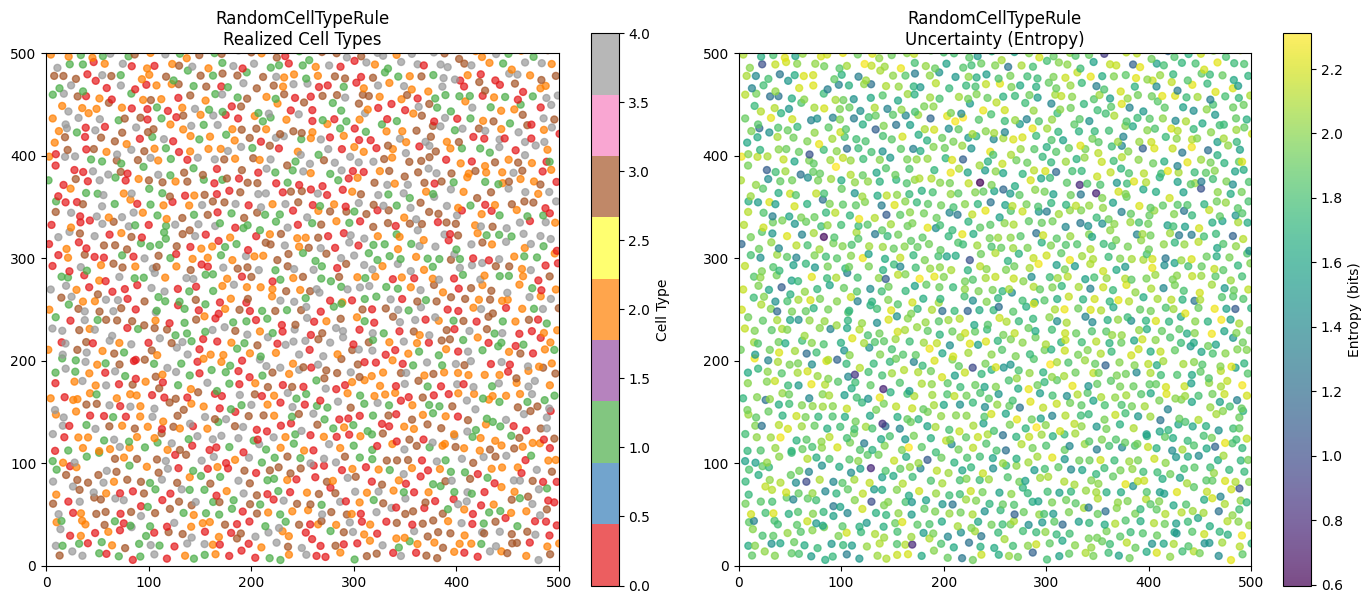

In [3]:
rule = RandomCellTypeRule(n_cell_types=5)
fov = visualize_rule(rule, "RandomCellTypeRule")

Notice the high entropy (uncertainty) - each cell has random probabilities across all types.

---
## 2. SingleTypeRule

All cells are assigned to a single cell type with probability ~1.0.

Useful for homogeneous regions or specific tissue compartments.

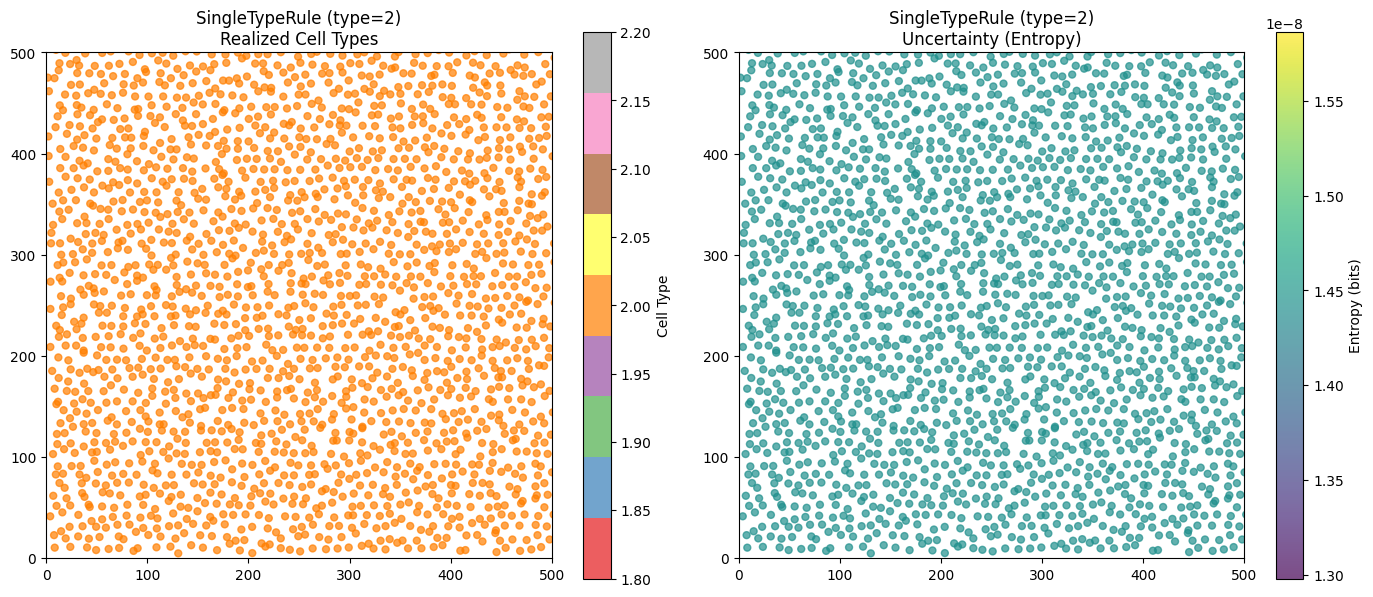

In [4]:
rule = SingleTypeRule(n_cell_types=5, cell_type_ix=2)
fov = visualize_rule(rule, "SingleTypeRule (type=2)")

Notice the very low entropy - all cells are confidently assigned to type 2.

---
## 3. MixOfNCellTypesRule

All cells receive the same fixed probability distribution over a subset of cell types.

Useful for regions with known cell type composition.

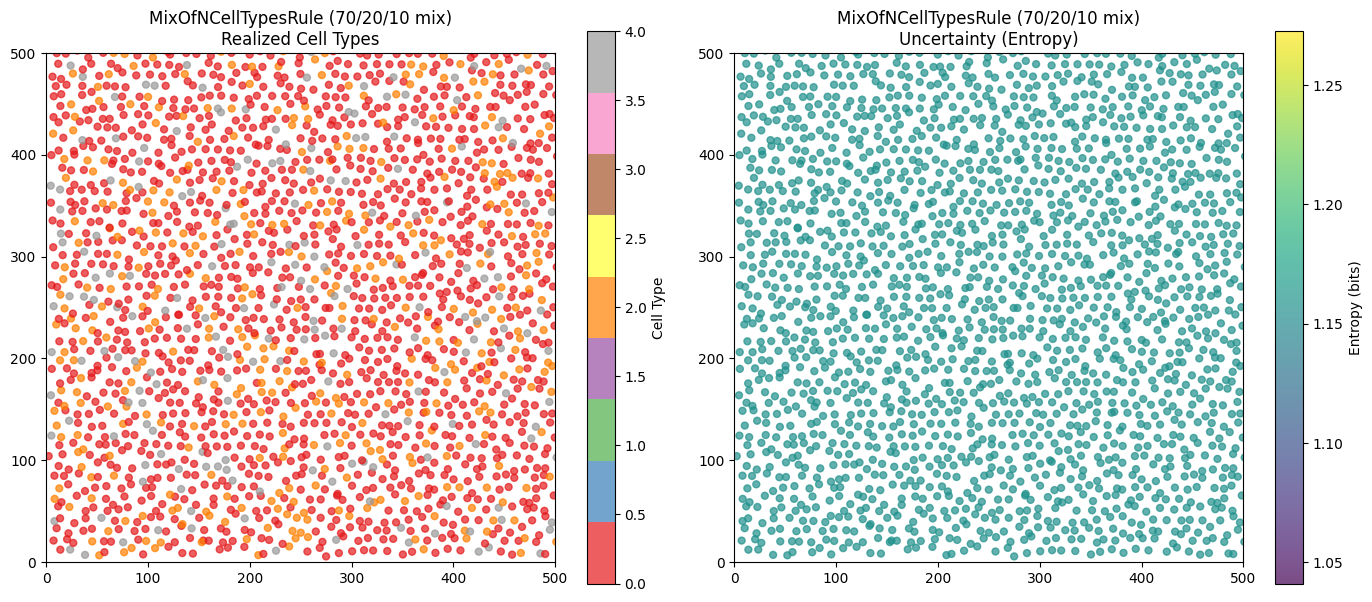

In [5]:
# 70% type 0, 20% type 2, 10% type 4
rule = MixOfNCellTypesRule(
    n_cell_types=5,
    list_N=[0, 2, 4],
    proportions=[0.7, 0.2, 0.1]
)
fov = visualize_rule(rule, "MixOfNCellTypesRule (70/20/10 mix)")

In [6]:
# Check the realized proportions
from collections import Counter
counts = Counter(fov.class_instance)
total = len(fov.class_instance)
print("Realized proportions:")
for t in sorted(counts.keys()):
    print(f"  Type {t}: {counts[t]:4d} cells ({100*counts[t]/total:.1f}%)")

Realized proportions:
  Type 0: 1390 cells (69.8%)
  Type 2:  401 cells (20.1%)
  Type 4:  201 cells (10.1%)


---
## 4. ProbabilityNodeFieldRule

Creates smooth spatial probability gradients by interpolating between reference points.

This is powerful for creating tissue regions with gradual cell type transitions.

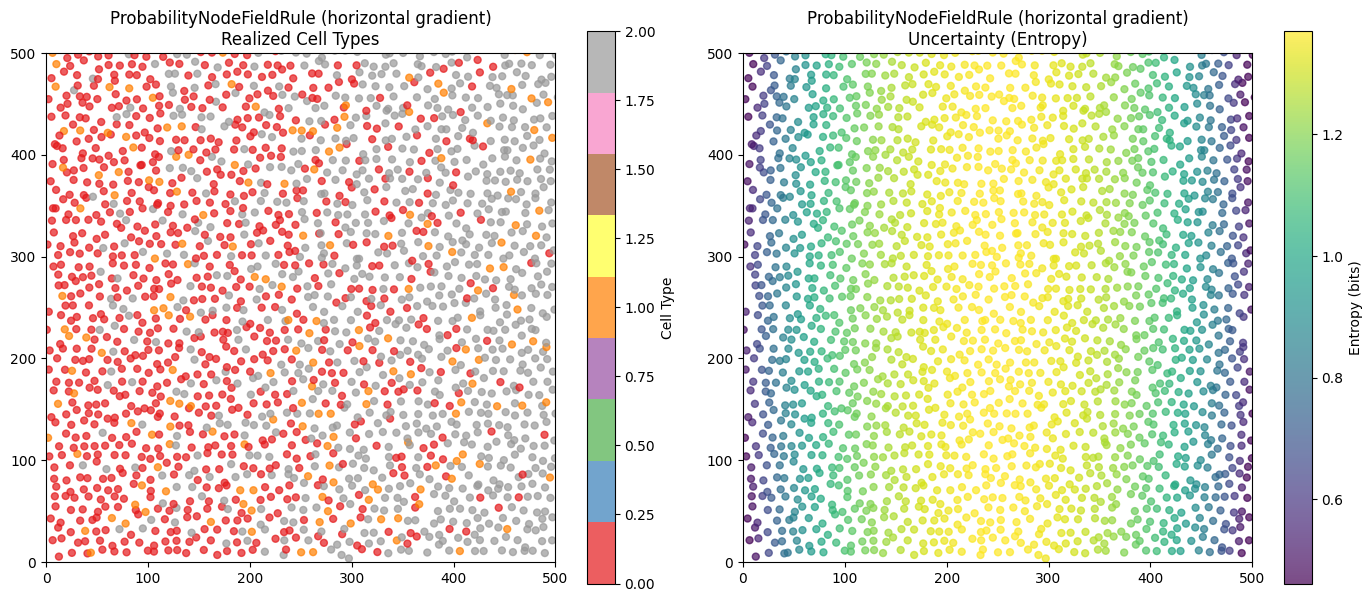

In [4]:
# Define reference points and their probability distributions
# We'll create a left-to-right gradient
frame_size = 500

reference_points = np.array([
    [50, 250],   # Left side
    [450, 250],  # Right side
])

# Probabilities at each reference point
# Left: mostly type 0, Right: mostly type 2
ref_probs = np.array([
    [0.8, 0.1, 0.1, 0.0, 0.0],  # Left
    [0.1, 0.1, 0.8, 0.0, 0.0],  # Right
])

rule = ProbabilityNodeFieldRule(
    n_cell_types=5,
    n_ref_points=2,
    ref_probs=ref_probs,
    reference_points=reference_points,
)

fov = visualize_rule(rule, "ProbabilityNodeFieldRule (horizontal gradient)")

/mnt/uplamanno/scratch/alireza/PointillSim/pointillsim/utils/interpolation.py:56: UserWarning: `degree` should not be below 1 except -1 when `kernel` is 'thin_plate_spline'.The interpolant may not be uniquely solvable, and the smoothing parameter may have an unintuitive effect.
  self.funcrbf = sp.interpolate.RBFInterpolator(self.points, self.values, degree=0)


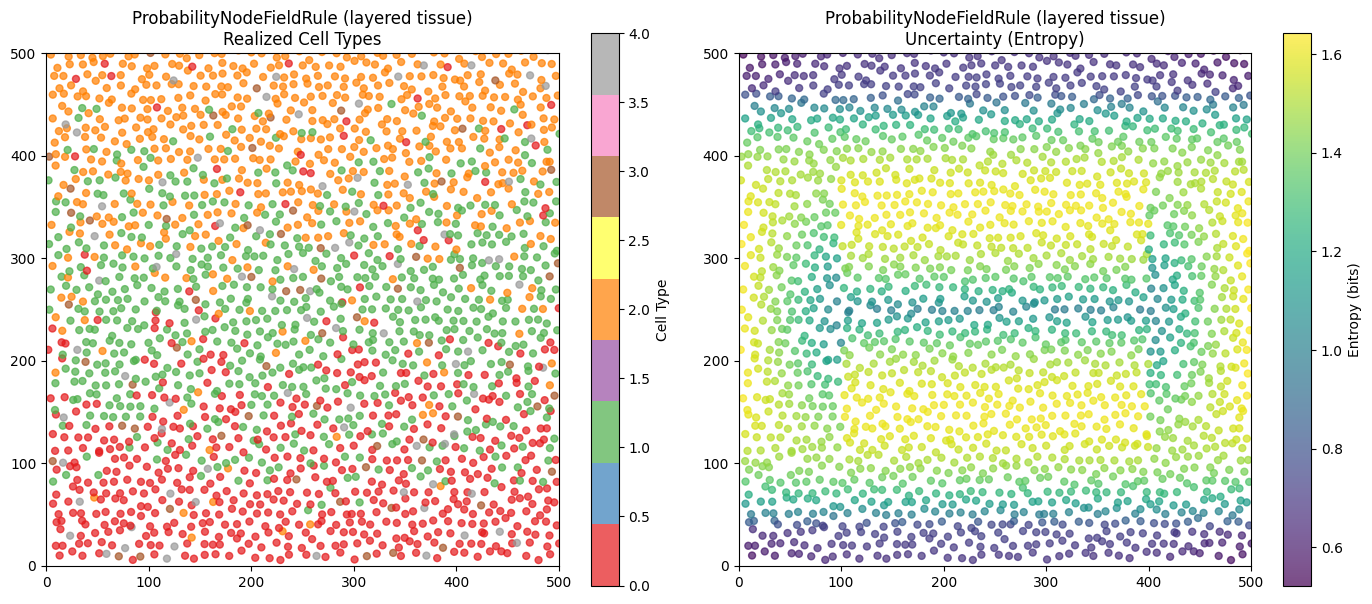

In [3]:
# More complex example: layered tissue (vertical gradient)
reference_points = np.array([
    [100, 50], [250, 50], [400, 50],     # Top
    [100, 250], [250, 250], [400, 250],  # Middle
    [100, 450], [250, 450], [400, 450],  # Bottom
])

# Convert logits to probabilities
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)

logits = np.array([
    # Top layer: type 0 dominant
    [3, 0, 0, 0, 0], [3, 0, 0, 0, 0], [3, 0, 0, 0, 0],
    # Middle layer: type 1 dominant
    [0, 3, 0, 0, 0], [0, 3, 0, 0, 0], [0, 3, 0, 0, 0],
    # Bottom layer: type 2 dominant
    [0, 0, 3, 0, 0], [0, 0, 3, 0, 0], [0, 0, 3, 0, 0],
])
ref_probs = softmax(logits)

rule = ProbabilityNodeFieldRule(
    n_cell_types=5,
    n_ref_points=9,
    ref_probs=ref_probs,
    reference_points=reference_points,
)

fov = visualize_rule(rule, "ProbabilityNodeFieldRule (layered tissue)")

---
## 5. DistanceBasedRule

Assigns cell types based on distance from element center or boundary.

Creates radial or concentric patterns - useful for structures like glands.

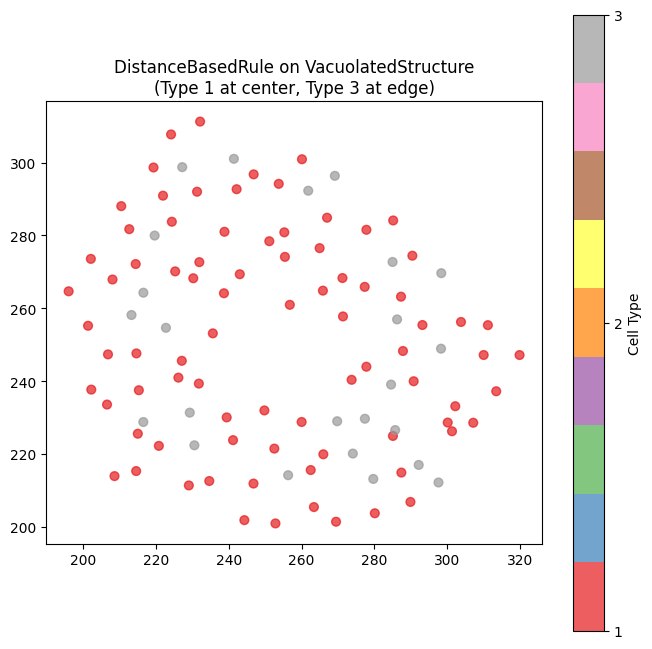

In [7]:
# Visualize on a VacuolatedStructure to see the radial effect
n_cell_types = 5

# Inner type at center, outer type at boundary
rule = DistanceBasedRule(
    n_cell_types=n_cell_types,
    reference="center",
    inner_type=1,  # Type at center
    outer_type=3,  # Type at edge
    transition_width=30,
)

# Create a single structure
structure = VacuolatedStructure(
    frame_size=500,
    scale=150,
    hole_scale_factor=0.3,
    fixed_center=np.array([[250, 250]]),
    rules=rule,
    tipical_cell_spacing=10,
).generate()

fig, ax = plt.subplots(figsize=(8, 8))
scatter = ax.scatter(
    structure.cell_centroids[:, 0],
    structure.cell_centroids[:, 1],
    c=structure.class_instance,
    cmap='Set1',
    s=40, alpha=0.7
)
ax.set_aspect('equal')
ax.set_title('DistanceBasedRule on VacuolatedStructure\n(Type 1 at center, Type 3 at edge)')
cbar = plt.colorbar(
    scatter,
    ax=ax,
    ticks=np.arange(n_cell_types)
)
cbar.set_label("Cell Type")
plt.show()

---
## 6. LayerRule

Creates concentric layers of different cell types.

Similar to cortical layers or onion-like structures.

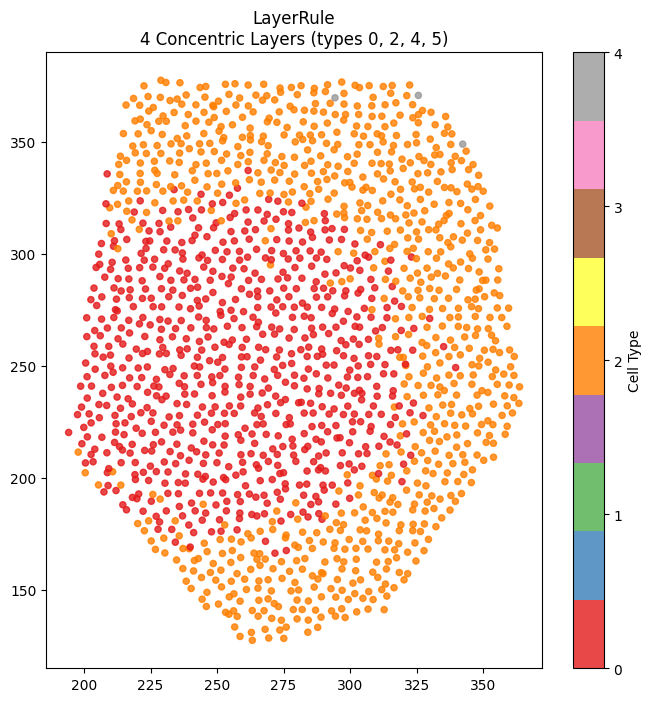

In [14]:
# 4 concentric layers
rule = LayerRule(
    n_cell_types=6,
    layer_types=[0, 2, 4, 5],  # Types from center outward
    layer_boundaries=[0.25, 0.5, 0.75],  # At 25%, 50%, 75% of radius
    transition_width=10,
)

structure = VacuolatedStructure(
    frame_size=500,
    scale=300,
    hole_scale_factor=0.0,  # Solid structure (no hole)
    fixed_center=np.array([[250, 250]]),
    rules=rule,
    tipical_cell_spacing=5,
).generate()

fig, ax = plt.subplots(figsize=(8, 8))
scatter = ax.scatter(
    structure.cell_centroids[:, 0],
    structure.cell_centroids[:, 1],
    c=structure.class_instance,
    cmap='Set1',
    s=20, alpha=0.8
)
ax.set_title('LayerRule\n4 Concentric Layers (types 0, 2, 4, 5)')
cbar = plt.colorbar(
    scatter,
    ax=ax,
    ticks=np.arange(6)
)
cbar.set_label("Cell Type")
plt.show()

---
## 7. GradientRule

Creates a linear gradient across a structure.

Cell types transition along a specified direction.

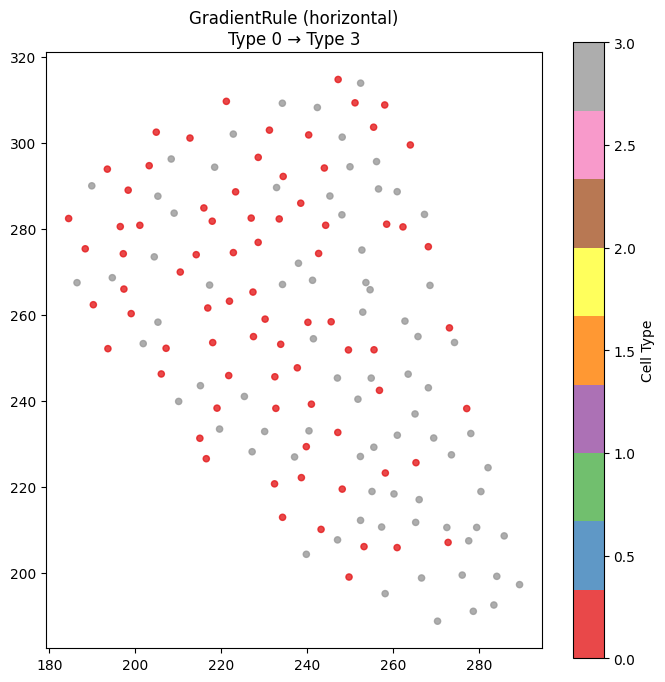

In [15]:
# Horizontal gradient
rule = GradientRule(
    n_cell_types=5,
    start_type=0,
    end_type=3,
    direction="horizontal",  # or "vertical", "diagonal", or (dx, dy)
    transition_width=0.4,
)

structure = VacuolatedStructure(
    frame_size=500,
    scale=180,
    hole_scale_factor=0.0,
    fixed_center=np.array([[250, 250]]),
    rules=rule,
    tipical_cell_spacing=8,
).generate()

fig, ax = plt.subplots(figsize=(8, 8))
scatter = ax.scatter(
    structure.cell_centroids[:, 0],
    structure.cell_centroids[:, 1],
    c=structure.class_instance,
    cmap='Set1',
    s=20, alpha=0.8
)
ax.set_aspect('equal')
ax.set_title('GradientRule (horizontal)\nType 0 → Type 3')
plt.colorbar(scatter, ax=ax, label='Cell Type')
plt.show()

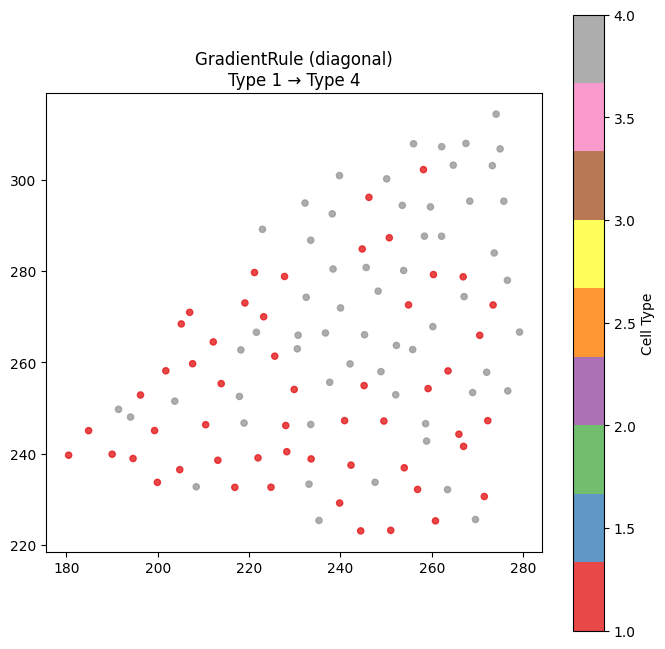

In [16]:
# Diagonal gradient
rule = GradientRule(
    n_cell_types=5,
    start_type=1,
    end_type=4,
    direction=(1, 1),  # Custom direction: bottom-left to top-right
    transition_width=0.3,
)

structure = VacuolatedStructure(
    frame_size=500,
    scale=180,
    hole_scale_factor=0.0,
    fixed_center=np.array([[250, 250]]),
    rules=rule,
    tipical_cell_spacing=8,
).generate()

fig, ax = plt.subplots(figsize=(8, 8))
scatter = ax.scatter(
    structure.cell_centroids[:, 0],
    structure.cell_centroids[:, 1],
    c=structure.class_instance,
    cmap='Set1',
    s=20, alpha=0.8
)
ax.set_aspect('equal')
ax.set_title('GradientRule (diagonal)\nType 1 → Type 4')
plt.colorbar(scatter, ax=ax, label='Cell Type')
plt.show()

---
## 8. CompositeRule

Combines multiple rules with configurable weights.

Useful for creating complex patterns that blend different spatial behaviors.

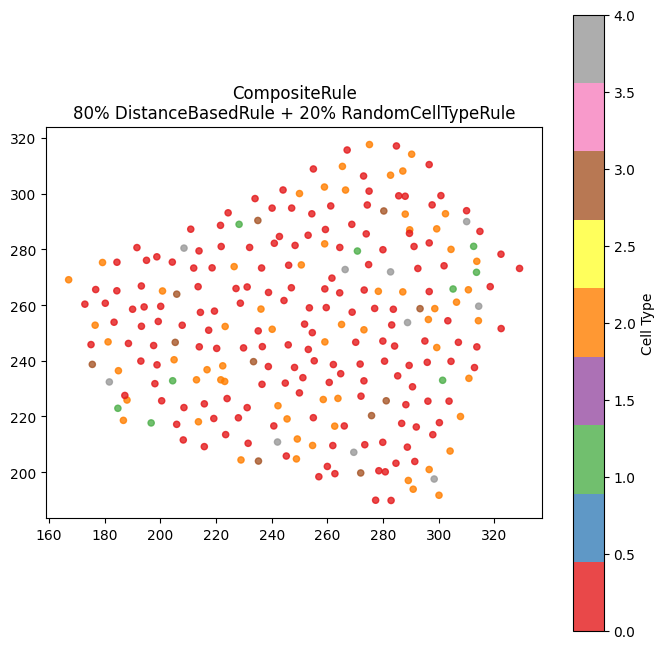

In [17]:
# Combine radial pattern with some randomness
radial_rule = DistanceBasedRule(
    n_cell_types=5,
    inner_type=0,
    outer_type=2,
    transition_width=40,
)

random_rule = RandomCellTypeRule(n_cell_types=5)

composite = CompositeRule(
    rules=[radial_rule, random_rule],
    weights=[0.8, 0.2],  # 80% radial, 20% random
    mode="average",
)

structure = VacuolatedStructure(
    frame_size=500,
    scale=180,
    hole_scale_factor=0.0,
    fixed_center=np.array([[250, 250]]),
    rules=composite,
    tipical_cell_spacing=8,
).generate()

fig, ax = plt.subplots(figsize=(8, 8))
scatter = ax.scatter(
    structure.cell_centroids[:, 0],
    structure.cell_centroids[:, 1],
    c=structure.class_instance,
    cmap='Set1',
    s=20, alpha=0.8
)
ax.set_aspect('equal')
ax.set_title('CompositeRule\n80% DistanceBasedRule + 20% RandomCellTypeRule')
plt.colorbar(scatter, ax=ax, label='Cell Type')
plt.show()

---
## Summary

| Rule | Use Case |
|------|----------|
| `RandomCellTypeRule` | Stochastic heterogeneous mixtures |
| `SingleTypeRule` | Homogeneous regions |
| `MixOfNCellTypesRule` | Fixed proportions throughout |
| `ProbabilityNodeFieldRule` | Smooth spatial gradients |
| `DistanceBasedRule` | Radial patterns (2 types) |
| `LayerRule` | Concentric rings (N types) |
| `GradientRule` | Linear gradients |
| `CompositeRule` | Combine multiple rules |

Rules can be applied to any histological element:
- `FrameWideElement` for full-frame backgrounds
- `VacuolatedStructure` for gland-like structures with holes
- `LinearLumenStructure` for tube-like vessels